# Signal types classification


Необходимо определить типы сигналов сцинтилляционного детектора. Ссылка на соревнование: https://www.kaggle.com/competitions/signal-types-classification/overview

## Описание задачи
В некоторых веществах в результате прохождения через них заряженных частиц возникают короткие вспышки света – сцинтилляции. Вещества, излучающие свет под действием ионизирующего излучения, называют сцинтилляторами.

Сцинтилляции отличны от остальных видов свечения, образующегося во время взаимодействия частиц с веществом тем, что они возникают вследствие электронных переходов внутри так называемых центров свечения. Такими центрами свечения могут служить, например, атомы, ионы, молекулы. Каждая вспышка вызвана отдельной заряженной частицей и состоит из большого количества (10^3 − 10^6) фотонов.

При получении данных, эксперименты с которыми производились в настоящей работе, был использован сцинтилляционный детектор, на основе органических кристаллов паратерфенила. Перспективность сцинтилляторов на основе органических кристаллов паратерфенила в регистрации нейтронного излучения в присутствии гамма-фона обуславливает большое содержание атомов водорода в вышеупомянутых элементах систем детектирования. Вызвано это тем, что для регистрации нейтронов используют эффект упругого рассеяния нейтронов с ядром.

При упругом рассеянии нейтронов на ядрах, наблюдается эффект отдачи кинетической энергии. Таким образом, вещество, из которого должен быть сделан сцинтиллятор, выбирается в соответствии с тем требованием, чтобы кинетическая энергия была максимально возможной. Наибольшее значение данной энергии наблюдается для ядер водорода. Именно поэтому высокое содержание водорода в используемом сцинтилляторе играет весомую роль в процессе детектирования излучения, содержащего в себе нейтроны.

P.s.: Данные к задаче были предоставлены лабораторией Национального исследовательского ядерного университета МИФИ.

## Оценка задачи
Задача оценивается с помощью метрики accuracy.

## Формат сдачи
Файл с ответами должен содержать две колонки: index and cluster. Учтите, что порядок номеров кластеров должен идти по порядку, т. е. после получения ответа вам необходимо сделать преобразование таким образом что номера кластеров будут идти по порядку.

Пример формата файла с ответами:
```
index,cluster
0,0
```



## Описание датасета
Вам даны данные о 23 479 сигналах с различных набором характеристик этих сигналов. Ваша задача кластеризовать эти сигналы на три кластера по типу сигналов: два кластера отображают типы сигналов (гамма-кванты или нейтроны), третий кластер представляет себя группу сигналов, которые не поддаются кластеризации. (Нумерация кластеров с 0: 0,1,2).

## Files
Run200_Wave_0_1.txt - набор данных о сигналах
test-dataset.ipynb - файл-пример чтения и отображения данных

# Решение

## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import holidays
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture

Я выполняю задание в google colab. Поэтому здесь идет автоматизация загрузки из локального и из облачного хранилища на всякий случай.

In [2]:
def read_file(filename: str = None, file_id: str = None) -> pd.DataFrame:
  try:
    try:
      # Сначала ищем файл локально
      return pd.read_csv(filename, sep=' ', header=None, skipinitialspace=True)
    except FileNotFoundError:
      # или путь в Колабе
      return pd.read_csv(f'/content/{filename}', sep=' ', header=None, skipinitialspace=True)
  except:
    try:
      import gdown
    except ImportError:
      !pip install gdown --quiet
      import gdown
    gdown.download(id=file_id, output="Run200_Wave_0_1.txt", quiet=True)
    return read_file(filename="Run200_Wave_0_1.txt")

filename = "Run200_Wave_0_1.txt"
link = " https://drive.google.com/file/d/1ir5oMxePKxDXSv23zpo6tzRnJBfMg70m/view?usp=sharing"

file_id = link[link.find("/d/") + 3:link.rfind("/view?")]
dataset: pd.DataFrame = read_file(filename, file_id)

## EDA

In [3]:
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()


,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [4]:
dataset.shape

(23479, 500)

Text(0, 0.5, 'bit ADC')

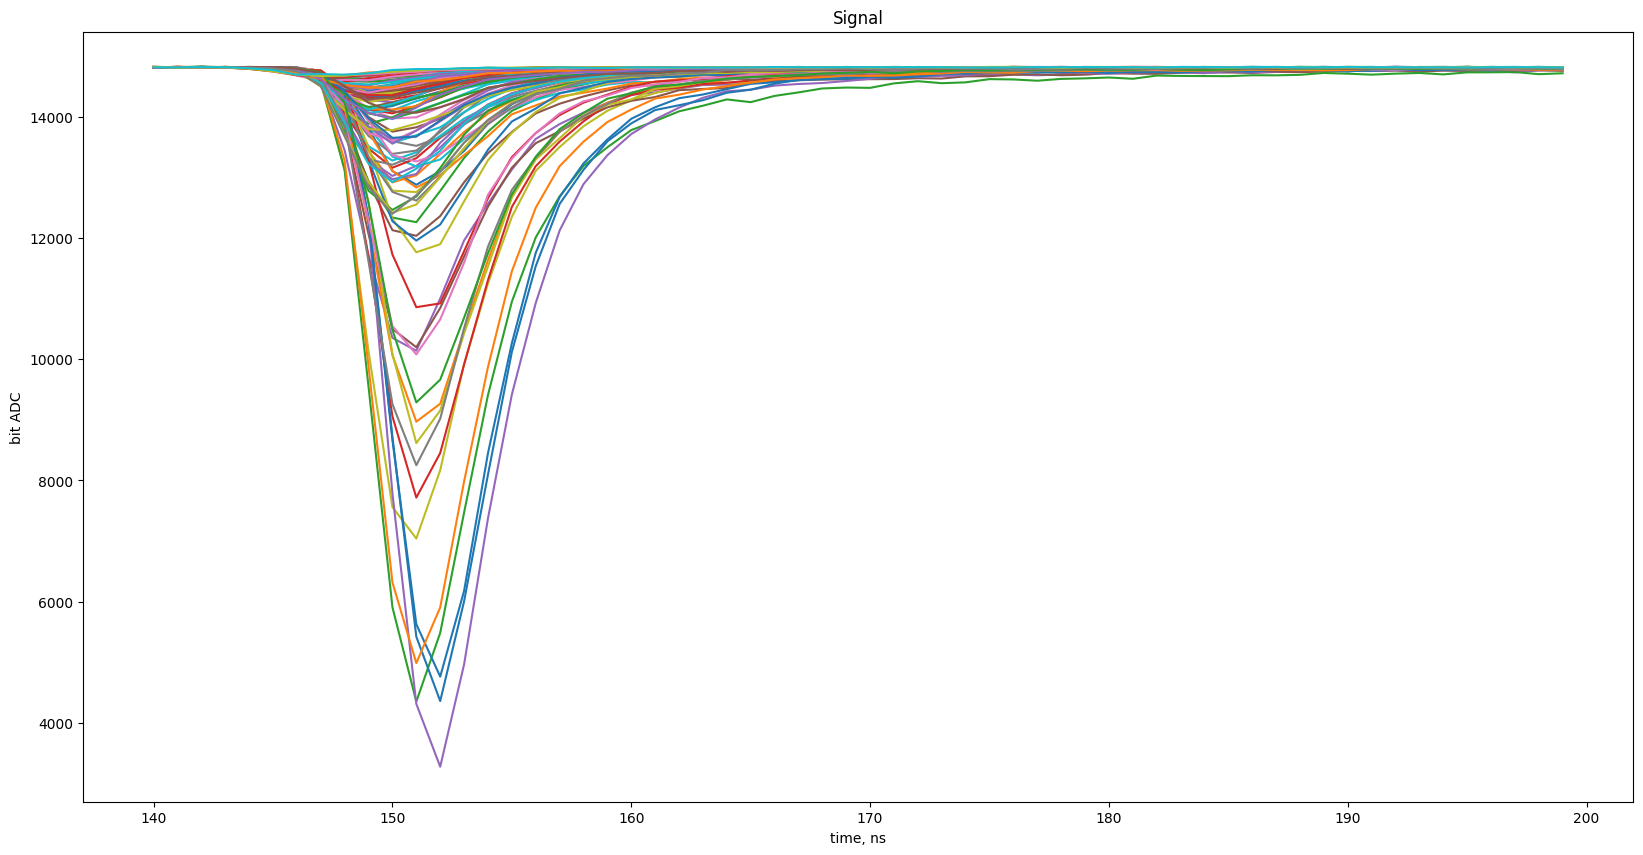

In [5]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

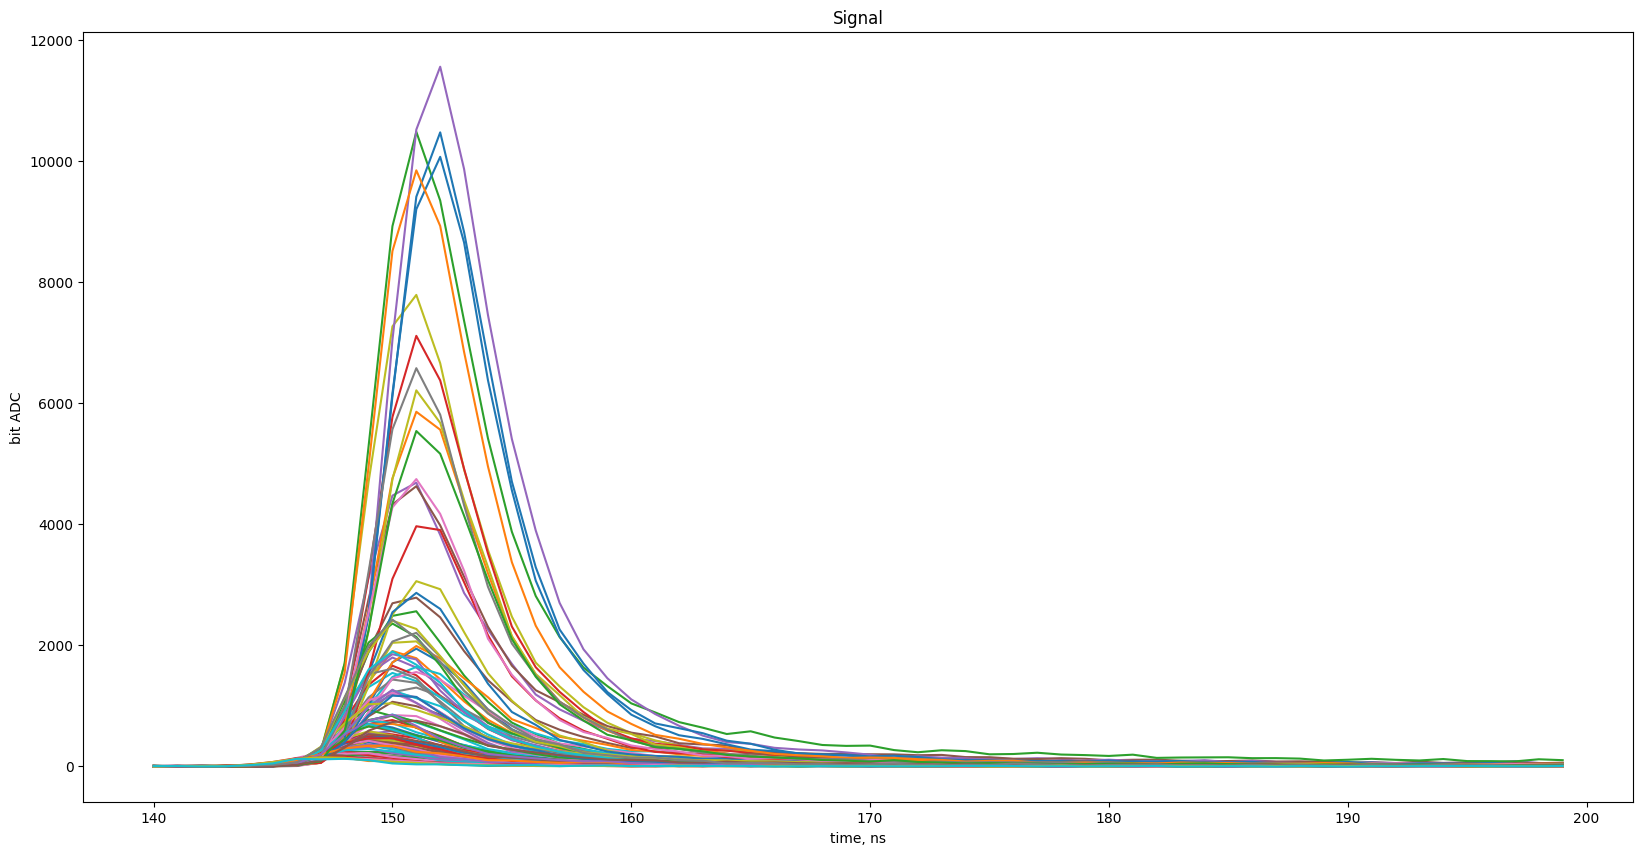

In [6]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


## Предобработка данных

In [7]:
raw = dataset.values.astype(np.float64)

# Инвертирование и коррекция сдвига (14-битный АЦП, смещение 1560)
signals = 2**14 - raw - 1560
baselines = np.median(signals[:, :50], axis=1, keepdims=True)
signals = signals - baselines

Вычисление и определение физических признаков для дальнейшего обучения моделей

In [8]:
def extract_features_v2(signals, tail_start=20,
                        window_end=450, start_threshold=0.2):
    """
    Для каждого сигнала идет вычисление:
    - amp           : амплитуда (максимум)
    - full_int      : интеграл от начала импульса до window_end
    - tail_int      : интеграл от peak+tail_start до window_end
    - psd           : tail_int / full_int
    """
    n = signals.shape[0]
    features = np.zeros((n, 4))
    for i in range(n):
        y = signals[i]
        peak = np.argmax(y)
        amp = y[peak]

        # Определение начала импульса по порогу start_threshold от амплитуды
        thr = start_threshold * amp
        start = peak
        for j in range(peak, -1, -1):
            if y[j] < thr:
                start = j
                break

        # Интегралы в фиксированном окне
        full_int = np.sum(y[start:window_end])
        tail_start_idx = min(peak + tail_start, window_end)
        tail_int = np.sum(y[tail_start_idx:window_end])

        psd = tail_int / (full_int + 1e-9)
        features[i] = [amp, full_int, tail_int, psd]
    return features

In [9]:
feat_array = extract_features_v2(signals)
feat_df = pd.DataFrame(feat_array,
                       columns=['amp', 'full_int', 'tail_int', 'psd'])

## Обучение моделей

### DBSCAN

Ещё вариант: DBSCAN, где eps подбирается автоматически по графику k-distance, плюс сама кластеризация.

In [10]:
# Масштабирование признаков (дальше в блокноте будет делаться так же)
features_for_clustering = ['amp', 'psd']
X = feat_df[features_for_clustering].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

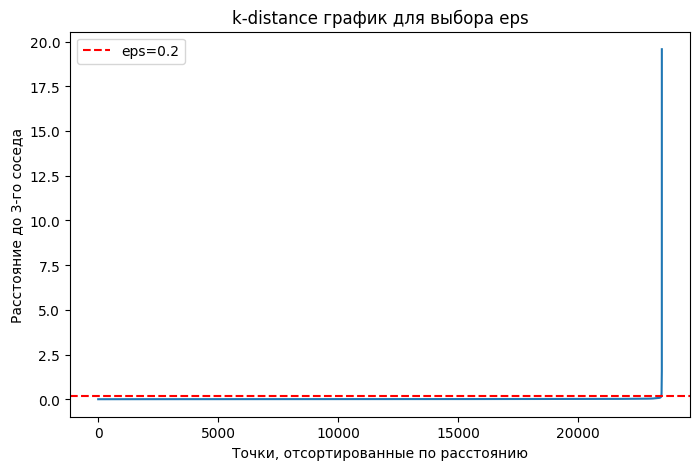

In [11]:
k = 3  # считается как min_samples-1
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.axhline(y=0.2, color='r', linestyle='--', label='eps=0.2')
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-distance график для выбора eps")
plt.legend()
plt.show()

In [12]:
eps = 0.3
min_samples = 10
db = DBSCAN(eps=eps, min_samples=min_samples)
db_clusters = db.fit_predict(X_scaled)

Найденные кластеры DBSCAN: {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
Распределение итоговых кластеров: [   13 23432    34]


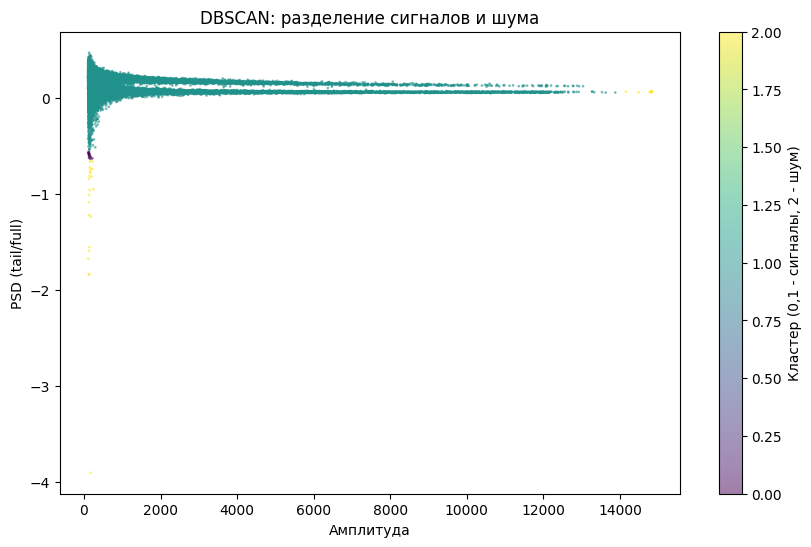

In [13]:
# Преобразование меток DBSCAN в целевые 0,1,2
# -1 (шум) -> 2
# остальные кластеры отсортированы по средней амплитуде и имеют метки 0 и 1

unique_clusters = set(db_clusters)
print("Найденные кластеры DBSCAN:", unique_clusters)

# Опредеоение шума
is_noise = (db_clusters == -1)
clusters_clean = db_clusters[~is_noise]
amp_clean = feat_df.loc[~is_noise, 'amp'].values

# Определение средней амплитуды для каждого кластера (кроме шума)
cluster_means = {}
for cl in np.unique(clusters_clean):
    mask = (clusters_clean == cl)
    cluster_means[cl] = np.mean(amp_clean[mask])

sorted_clusters = sorted(cluster_means.keys(), key=lambda c: cluster_means[c])
# Назначение 0 и 1 двум крупнейшим кластерам (если их больше двух, выберем два с наибольшим числом точек)
if len(sorted_clusters) >= 2:
    mapping = {sorted_clusters[0]: 0, sorted_clusters[1]: 1}
else:
    mapping = {sorted_clusters[0]: 0}  # fallback

final_clusters = np.full_like(db_clusters, 2)  # всё сначала шум (2)
for orig, new in mapping.items():
    final_clusters[db_clusters == orig] = new

print("Распределение итоговых кластеров:", np.bincount(final_clusters))

#Визуализация
plt.figure(figsize=(10,6))
plt.scatter(feat_df['amp'], feat_df['psd'], c=final_clusters, cmap='viridis', alpha=0.5, s=1)
plt.xlabel('Амплитуда')
plt.ylabel('PSD (tail/full)')
plt.colorbar(label='Кластер (0,1 - сигналы, 2 - шум)')
plt.title('DBSCAN: разделение сигналов и шума')
plt.show()

Как видно из графика, модель DBSCAN очень плохо различает кластеры и вообще не подходит для этой задачи, так что в дальнейшем я отказалась от её использования.

### KMeans

In [14]:
# Масштабирование признаков
features_to_use = [
    'psd'
    ]  # основная разделительная сила – только PSD.

X = feat_df[features_to_use].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Кластеризация KMeans

Распределение по кластерам: [12610 10621   248]


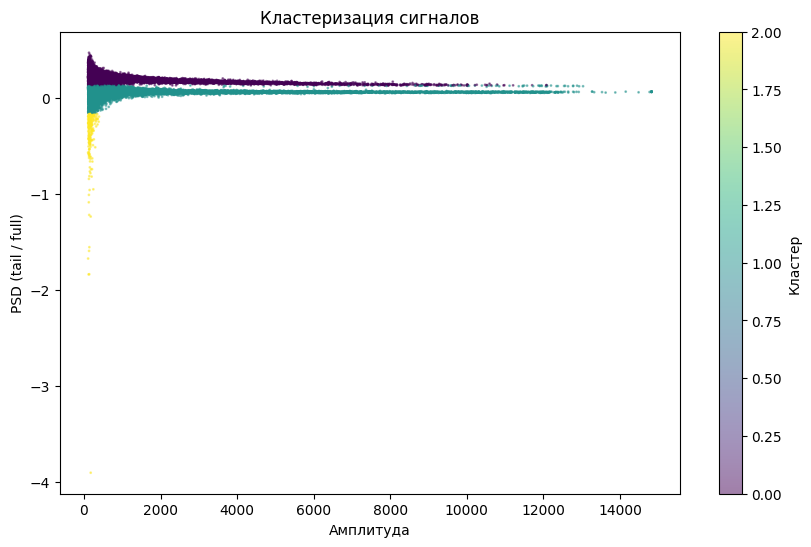

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
clusters_raw = kmeans.fit_predict(X_scaled)

# Приведение меток кластеров к последовательным 0,1,2 с помощью Label Encoder
le = LabelEncoder()
clusters = le.fit_transform(clusters_raw)
print("Распределение по кластерам:", np.bincount(clusters))

# Визуализация
plt.figure(figsize=(10,6))
scatter = plt.scatter(feat_df['amp'], feat_df['psd'], c=clusters,
                      cmap='viridis', alpha=0.5, s=1)
plt.xlabel('Амплитуда')
plt.ylabel('PSD (tail / full)')
plt.colorbar(scatter, label='Кластер')
plt.title('Кластеризация сигналов')
plt.show()

Принудительное выделение шума

In [16]:
lower_perc = 0.5   # нижний процентиль
upper_perc = 100  # верхний процентиль
psd_low = np.percentile(feat_df['psd'], lower_perc)
psd_high = np.percentile(feat_df['psd'], upper_perc)
print(f"Границы PSD по процентилям: \
        нижняя={psd_low:.4f}, верхняя={psd_high:.4f}")
noise_mask = (feat_df['psd'] < psd_low) | (feat_df['psd'] > psd_high)
print(f"Шумовых событий: {noise_mask.sum()}")

Границы PSD по процентилям:         нижняя=-0.2811, верхняя=0.4676
Шумовых событий: 118


Распределение KMeans только по PSD: [12697 10664   118]


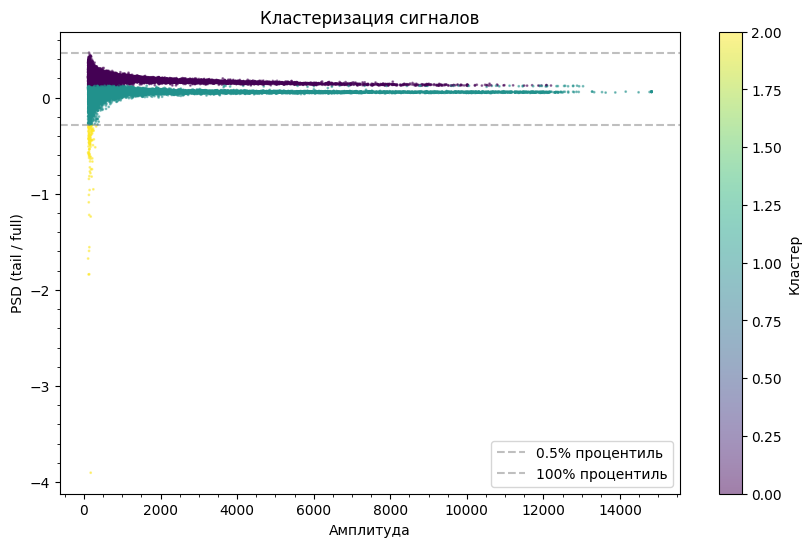

In [17]:
# Выделение PSD для сигнальных событий и масштабировние
psd_clean = feat_df.loc[~noise_mask, 'psd'].values.reshape(-1, 1)
scaler_psd = StandardScaler()
psd_scaled = scaler_psd.fit_transform(psd_clean)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(psd_scaled)

# Расстановка меток: 0 и 1 – сигналы, упорядоченные по средней амплитуде, 2 – шум
final_kmeans = np.full(len(feat_df), 2, dtype=int)
signal_indices = np.where(~noise_mask)[0]

amp_signal = feat_df.loc[~noise_mask, 'amp'].values
mean_amp_clusters = {}
for cl in np.unique(kmeans_clusters):
    mean_amp_clusters[cl] = np.mean(amp_signal[kmeans_clusters == cl])
sorted_cl = sorted(mean_amp_clusters.keys(), key=lambda c: mean_amp_clusters[c])
mapping = {sorted_cl[0]: 0, sorted_cl[1]: 1}
for i, idx in enumerate(signal_indices):
    final_kmeans[idx] = mapping[kmeans_clusters[i]]

print("Распределение KMeans только по PSD:", np.bincount(final_kmeans))

#Визуализация
plt.figure(figsize=(10,6))
scatter = plt.scatter(feat_df['amp'], feat_df['psd'], c=final_kmeans,
                      cmap='viridis', alpha=0.5, s=1)
plt.xlabel('Амплитуда')
plt.ylabel('PSD (tail / full)')
plt.colorbar(scatter, label='Кластер')
plt.title('Кластеризация сигналов')
plt.axhline(y=psd_low, color='grey', linestyle='--',
            label=f'{lower_perc}% процентиль', alpha=0.5)
plt.axhline(y=psd_high, color='grey', linestyle='--',
            label=f'{upper_perc}% процентиль', alpha=0.5)
plt.legend()
plt.minorticks_on()
plt.show()

Ручное отсечение хвостов + KMeans даёт 78% на тесте Kaggle. Сам по себе KMeans без отсечения хвостов почти столько же выдаёт. Результат хороший, но на графике видно, что в пиках амплитуды кластеры смешиваются. Попробую другие алгоритмы, но этот запомню — он эффективный, даже несмотря на небольшое ручное вмешательство

### Gaussian Matrix

In [18]:
# Признаки для кластеризации – amp и psd
X = feat_df[['amp', 'psd']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# Gaussian Mixture с 3 компонентами и полной ковариацией
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Шумовой кластер - наименьшая средняя амплитуда
cluster_amp_means = {}
for cl in np.unique(gmm_labels):
    mask = (gmm_labels == cl)
    cluster_amp_means[cl] = np.mean(feat_df.loc[mask, 'amp'])

noise_cluster = min(cluster_amp_means, key=cluster_amp_means.get)

Распределение Gaussian Mixture: [ 5391  5431 12657]
Средние амплитуды кластеров:
  Кластер 0: amp=2757.3,     psd=0.1745
  Кластер 1: amp=4249.9,     psd=0.0596
  Кластер 2: amp=406.3,     psd=0.1373


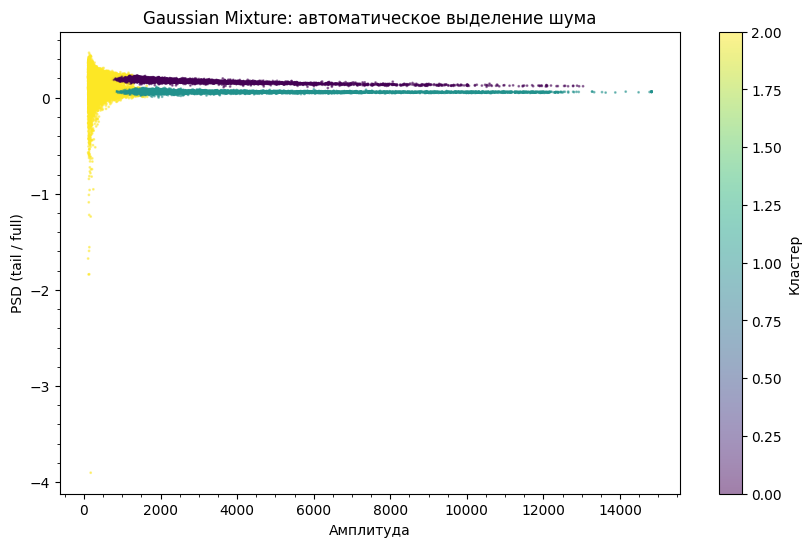

In [20]:
# Итоговые метки: сигналы -> 0/1 (сортируем по средней амплитуде), шум -> 2
final_gauss = np.full(len(feat_df), -1, dtype=int)
final_gauss[gmm_labels == noise_cluster] = 2

remaining = [cl for cl in np.unique(gmm_labels) if cl != noise_cluster]
rem_amp = {cl: cluster_amp_means[cl] for cl in remaining}
sorted_cl = sorted(rem_amp, key=rem_amp.get)
final_gauss[gmm_labels == sorted_cl[0]] = 0
final_gauss[gmm_labels == sorted_cl[1]] = 1

print("Распределение Gaussian Mixture:", np.bincount(final_gauss))
print("Средние амплитуды кластеров:")
for c in [0, 1, 2]:
    mask = (final_gauss == c)
    print(f"  Кластер {c}: amp={np.mean(feat_df.loc[mask, 'amp']):.1f}, \
    psd={np.mean(feat_df.loc[mask, 'psd']):.4f}")

#Визуализация
plt.figure(figsize=(10,6))
scatter = plt.scatter(feat_df['amp'], feat_df['psd'], c=final_gauss, cmap='viridis', alpha=0.5, s=1)
plt.xlabel('Амплитуда')
plt.ylabel('PSD (tail / full)')
plt.colorbar(scatter, label='Кластер')
plt.title('Gaussian Mixture: автоматическое выделение шума')
plt.minorticks_on()
plt.show()

Данный метод демонстрирует визуально более качественное разделение выборки на первый взгляд, однако при тестировании его точность оказывается ниже 50%. В качестве возможного улучшения можно рассмотреть ручное отсечение «хвостов» распределения — это позволит свести задачу к выделению моделью только двух кластеров.

In [21]:
# Отсечение шума по PSD (процентили снизу и сверху)
lower_perc = 0.5   # нижний процентиль (отсекаем отрицательный хвост шума)
upper_perc = 100.0  # верхний процентиль (убираем возможные выбросы)
psd_low = np.percentile(feat_df['psd'], lower_perc)
psd_high = np.percentile(feat_df['psd'], upper_perc)
print(f"Границы PSD по процентилям: нижняя={psd_low:.4f}, верхняя={psd_high:.4f}")

noise_mask = (feat_df['psd'] < psd_low) | (feat_df['psd'] > psd_high)
print(f"Шумовых событий: {noise_mask.sum()}")

Границы PSD по процентилям: нижняя=-0.2811, верхняя=0.4676
Шумовых событий: 118


In [22]:
X_signal = feat_df.loc[~noise_mask, ['psd']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_signal)

Распределение итоговых меток (0,1,2): [12345 11016   118]
Средние характеристики кластеров:
  Кластер 0: amp=1299.7, psd=0.2009
  Кластер 1: amp=2453.2, psd=0.0534
  Кластер 2: amp=162.1, psd=-0.5593


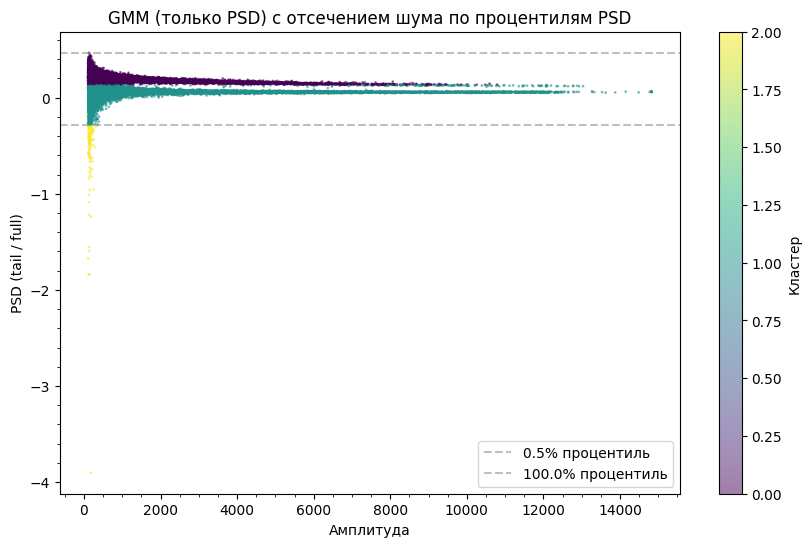

In [23]:
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

final_gauss = np.full(len(feat_df), 2, dtype=int)
signal_idx = np.where(~noise_mask)[0]
amp_signal = feat_df.loc[~noise_mask, 'amp'].values

cluster_means = {}
for cl in np.unique(gmm_labels):
    cluster_means[cl] = np.mean(amp_signal[gmm_labels == cl])
sorted_cl = sorted(cluster_means, key=lambda c: cluster_means[c])
mapping = {sorted_cl[0]: 0, sorted_cl[1]: 1}

final_gauss[signal_idx] = [mapping[l] for l in gmm_labels]

print("Распределение итоговых меток (0,1,2):", np.bincount(final_gauss))
print("Средние характеристики кластеров:")
for c in [0, 1, 2]:
    mask = (final_gauss == c)
    print(f"  Кластер {c}: amp={np.mean(feat_df.loc[mask, 'amp']):.1f}, psd={np.mean(feat_df.loc[mask, 'psd']):.4f}")

# Визуализация
plt.figure(figsize=(10,6))
scatter = plt.scatter(feat_df['amp'], feat_df['psd'], c=final_gauss, cmap='viridis', alpha=0.5, s=1)
plt.axhline(y=psd_low, color='grey', linestyle='--', label=f'{lower_perc}% процентиль', alpha=0.5)
plt.axhline(y=psd_high, color='grey', linestyle='--', label=f'{upper_perc}% процентиль', alpha=0.5)
plt.xlabel('Амплитуда')
plt.ylabel('PSD (tail / full)')
plt.colorbar(scatter, label='Кластер')
plt.title('GMM (только PSD) с отсечением шума по процентилям PSD')
plt.legend()
plt.minorticks_on()
plt.show()

Данная модель также показывает более удовлетворительные результаты, чем Kmeans и превосходит её по рейтингу в рамках соревнования, в связи с чем я принимаю решение оставить именно эту модель.

## Выгрузка в файл

In [24]:
submission = pd.DataFrame({'index': np.arange(len(final_gauss)), 'cluster': final_gauss})
submission
submission.to_csv('submission_gauss.csv', index=False)

Скриншот из соревнования:

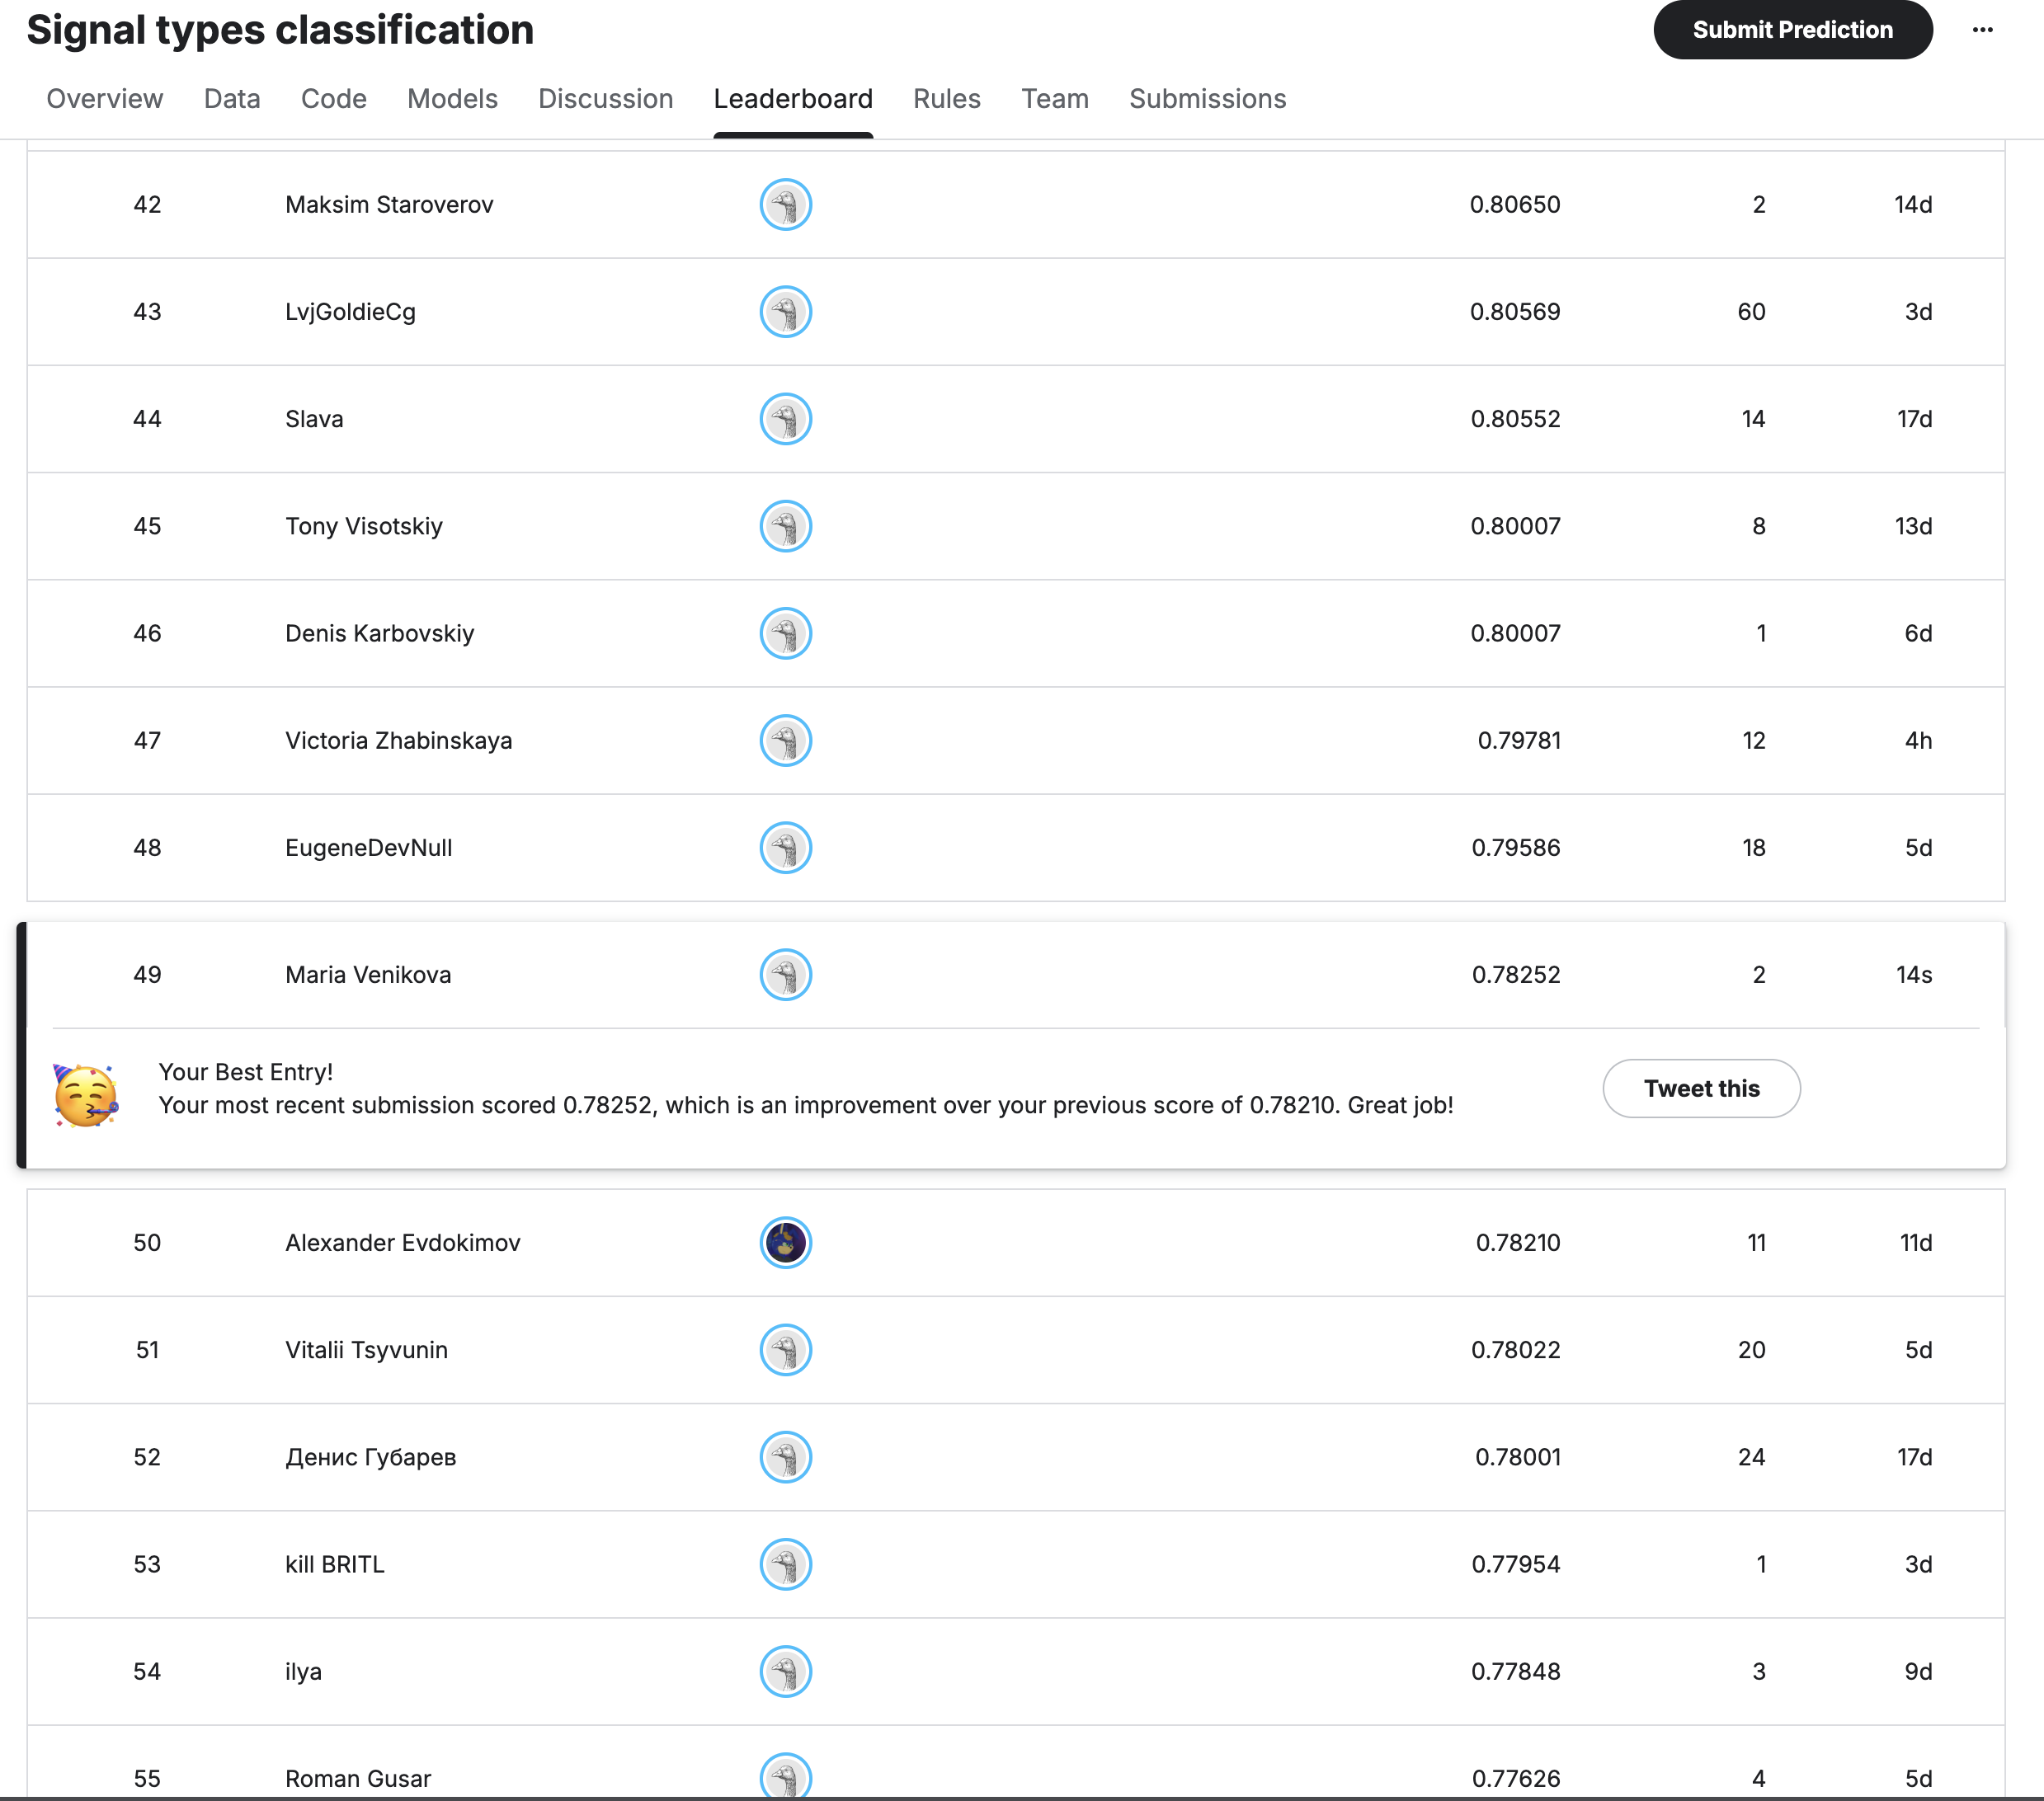